In [1]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    if files:
        print(root)
        print(files[:5])
    

/kaggle/input/datasets/joaomarcosgil/dataset-machine-learning/dataset-machine-learning/valid/labels
['LMB-6506_jpg.rf.0dc09f8fe8a6e759d255a7f53f944546.txt', 'BCJ2F74_motorcycle_20240729004403042_jpg.rf.53a169d34718e62c5cb0e559d62fc4d6.txt', 'treino-286-_jpg.rf.a73044fbc04b6dc50454292308dfa43b.txt', 'treino-41-_jpg.rf.759e5ecc284286f4a3ad62546388e605.txt', 'MEB9550_pickuptruck_20240725111021730_jpg.rf.c3ca670f97807da05f11903669ce54aa.txt']
/kaggle/input/datasets/joaomarcosgil/dataset-machine-learning/dataset-machine-learning/valid/images
['KQL-9716_jpg.rf.cac421e2ba98fa34ccaaccd6f125c0fa.jpg', 'treino-201-_jpg.rf.52f3894adf78ca445615d0a41528ec40.jpg', 'LQY-3816_jpg.rf.8099a8ee5bf787585abc7d5f4e9c99b0.jpg', 'treino-332-_jpg.rf.dc26103caac6d23cd9dd310fd572cd1f.jpg', 'RVL3C23_sedan_20240727211822303_jpg.rf.c58ddb5addc757b83fc9d4e12d2d1609.jpg']
/kaggle/input/datasets/joaomarcosgil/dataset-machine-learning/dataset-machine-learning/test/labels
['treino-377-_jpg.rf.ffdd2d17196322e3ff1aa9f77c7

In [2]:
import os

base_dataset = '/kaggle/input/datasets/joaomarcosgil/dataset-machine-learning/dataset-machine-learning'

for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(base_dataset, split, 'images')
    lbl_dir = os.path.join(base_dataset, split, 'labels')

    print(f'\n{split.upper()}')
    print('Imagens:', len(os.listdir(img_dir)) if os.path.exists(img_dir) else 'pasta não encontrada')
    print('Labels:', len(os.listdir(lbl_dir)) if os.path.exists(lbl_dir) else 'pasta não encontrada')


TRAIN
Imagens: 4292
Labels: 4292

VALID
Imagens: 391
Labels: 391

TEST
Imagens: 276
Labels: 276


In [3]:
label_exemplo = os.path.join(base_dataset, 'train', 'labels', os.listdir(os.path.join(base_dataset, 'train', 'labels'))[0])

print("Arquivo:", label_exemplo)

with open(label_exemplo, 'r') as f:
    print(f.read())

Arquivo: /kaggle/input/datasets/joaomarcosgil/dataset-machine-learning/dataset-machine-learning/train/labels/ATI6253_sedan_20240726084857605_jpg.rf.11564d953176714e5c2df154a7b3c241.txt
0 0.35714285714285715 0.8146067415730337 0.22767857142857142 0.12359550561797752


In [4]:
import yaml

data_config = {
    'path': base_dataset,
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': 1,
    'names': ['placa']
}

with open('/kaggle/working/data.yaml', 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False, sort_keys=False)

print("data.yaml criado com sucesso!")

with open('/kaggle/working/data.yaml', 'r') as f:
    print(f.read())

data.yaml criado com sucesso!
path: /kaggle/input/datasets/joaomarcosgil/dataset-machine-learning/dataset-machine-learning
train: train/images
val: valid/images
test: test/images
nc: 1
names:
- placa



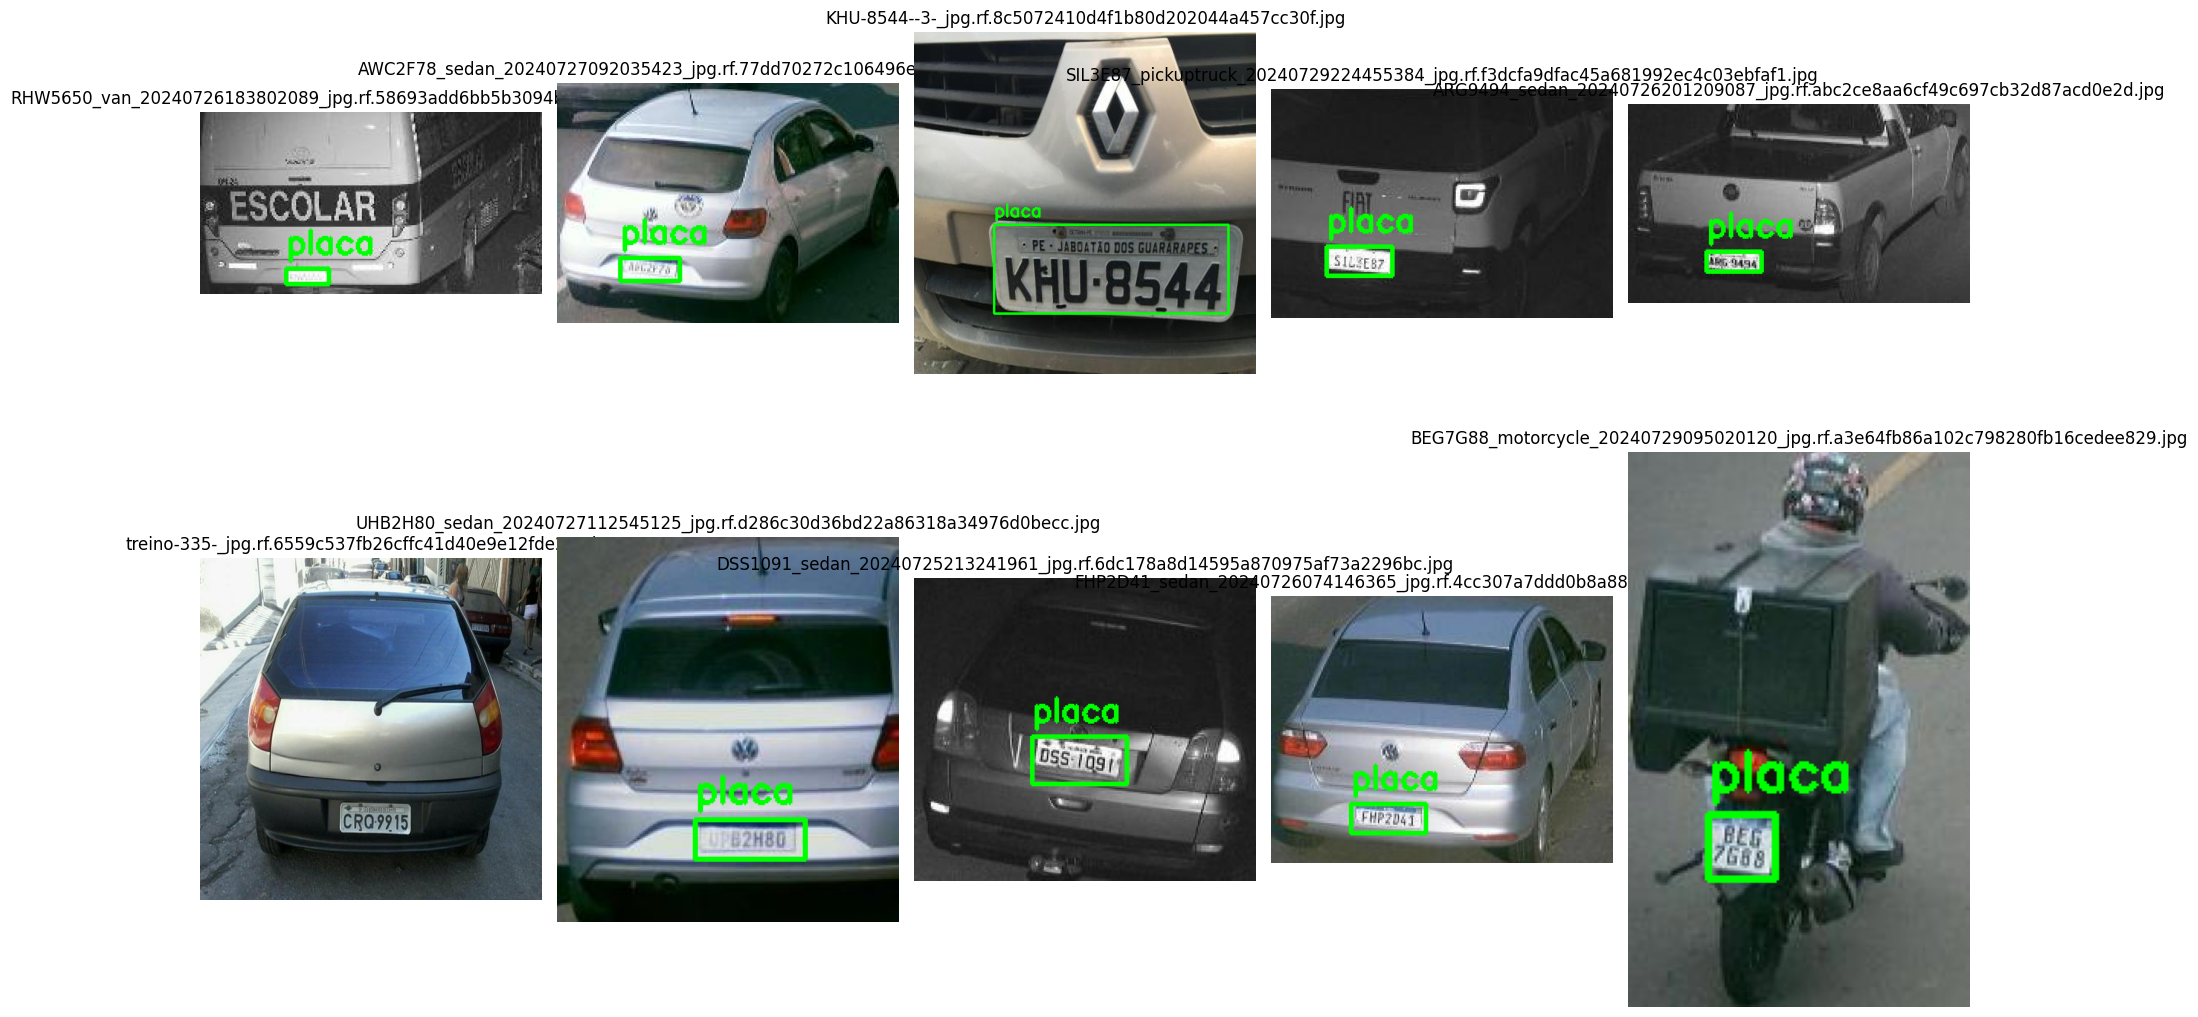

In [5]:
import cv2
import random
import matplotlib.pyplot as plt

img_dir = os.path.join(base_dataset, 'train', 'images')
lbl_dir = os.path.join(base_dataset, 'train', 'labels')

imgs = random.sample(
    [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))],
    10
)

plt.figure(figsize=(18, 12))

for i, img_name in enumerate(imgs, 1):
    img_path = os.path.join(img_dir, img_name)
    lbl_path = os.path.join(lbl_dir, os.path.splitext(img_name)[0] + '.txt')

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()

            if len(parts) != 5:
                continue

            cls, xc, yc, bw, bh = map(float, parts)

            x1 = int((xc - bw / 2) * w)
            y1 = int((yc - bh / 2) * h)
            x2 = int((xc + bw / 2) * w)
            y2 = int((yc + bh / 2) * h)

            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(
                img,
                'placa',
                (x1, max(20, y1 - 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 255, 0),
                2
            )

    plt.subplot(2, 5, i)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
# Instalar e importar o YOLO

!pip install ultralytics -q

import torch
from ultralytics import YOLO

print(f"GPU disponível: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 609.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 57.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23

In [7]:
# Treinar o YOLOv11

model = YOLO('yolo11n.pt')

results = model.train(
    data='/kaggle/working/data.yaml',
    epochs=50,
    imgsz=640,
    name='experimento_placas_classe_unica',
    project='ML_Placas_Veiculares',
    device=0
)

print(f"Treino finalizado!")
print(f"Melhor modelo em: {results.save_dir}/weights/best.pt")

Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=experimento_placas_classe_unica, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

In [8]:
# Avaliar no conjunto de teste

best_model_path = f"{results.save_dir}/weights/best.pt"

model_yolo = YOLO(best_model_path)

metrics = model_yolo.val(
    data='/kaggle/working/data.yaml',
    split='test'
)

print(metrics)

Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 1.6±0.2 ms, read: 12.2±3.7 MB/s, size: 46.4 KB)
val: Scanning /kaggle/input/datasets/joaomarcosgil/dataset-machine-learning/dataset-machine-learning/test/labels... 276 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 276/276 305.6it/s 0.9s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/joaomarcosgil/dataset-machine-learning/dataset-machine-learning/test is not writable, cache not saved.
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 53, len(boxes) = 278. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 5.7it/s 3.1s
   

In [9]:
# Gerar detecções e recortes das placas

import pandas as pd

test_images_path = os.path.join(base_dataset, 'test', 'images')

output_detected = '/kaggle/working/resultado_deteccoes'
output_crops = '/kaggle/working/recortes_placas'

os.makedirs(output_detected, exist_ok=True)
os.makedirs(output_crops, exist_ok=True)

final_data_yolo = []

imagens = [
    f for f in os.listdir(test_images_path)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

for img_name in imagens:
    path = os.path.join(test_images_path, img_name)
    img = cv2.imread(path)

    if img is None:
        continue

    preds = model_yolo.predict(img, conf=0.25, verbose=False)

    deteccoes = 0

    for r in preds:
        for box in r.boxes:
            deteccoes += 1

            cls_id = int(box.cls[0])
            label = model_yolo.names[cls_id]
            conf_det = float(box.conf[0])

            x1, y1, x2, y2 = map(int, box.xyxy[0])

            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(img.shape[1], x2)
            y2 = min(img.shape[0], y2)

            crop = img[y1:y2, x1:x2]

            if crop.size == 0:
                continue

            crop_name = f"{os.path.splitext(img_name)[0]}_placa_{deteccoes}.jpg"
            crop_path = os.path.join(output_crops, crop_name)

            cv2.imwrite(crop_path, crop)

            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(
                img,
                f"{label} {conf_det:.2f}",
                (x1, max(20, y1 - 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 255, 0),
                2
            )

            final_data_yolo.append({
                "Imagem": img_name,
                "Classe": label,
                "Confianca": conf_det,
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "Recorte": crop_name
            })

    if deteccoes == 0:
        final_data_yolo.append({
            "Imagem": img_name,
            "Classe": "NAO_DETECTADO",
            "Confianca": 0.0,
            "x1": None,
            "y1": None,
            "x2": None,
            "y2": None,
            "Recorte": None
        })

    cv2.imwrite(os.path.join(output_detected, img_name), img)

df_yolo = pd.DataFrame(final_data_yolo)
df_yolo.to_csv('/kaggle/working/resultados_yolo.csv', index=False)

print("Processamento finalizado.")
print(f"Imagens com detecção: {output_detected}")
print(f"Recortes das placas: {output_crops}")
print(f"CSV salvo em: /kaggle/working/resultados_yolo.csv")
print(f"Total de registros: {len(df_yolo)}")

df_yolo.head()

Processamento finalizado.
Imagens com detecção: /kaggle/working/resultado_deteccoes
Recortes das placas: /kaggle/working/recortes_placas
CSV salvo em: /kaggle/working/resultados_yolo.csv
Total de registros: 279


,Imagem,Classe,Confianca,x1,y1,x2,y2,Recorte
0,PXJ-8271-4-_jpg.rf.52d2f50e206bd6575117b86e1bd...,placa,0.812751,209,354,464,475,PXJ-8271-4-_jpg.rf.52d2f50e206bd6575117b86e1bd...
1,137_jpg.rf.532cef6e3efed680df8242f7f33bf170.jpg,placa,0.898192,379,398,424,428,137_jpg.rf.532cef6e3efed680df8242f7f33bf170_pl...
2,400_jpg.rf.4091d2046cd84961a30e4c12b86a37fc.jpg,placa,0.849146,350,348,405,380,400_jpg.rf.4091d2046cd84961a30e4c12b86a37fc_pl...
3,1034_jpg.rf.9bfc3ba376e686e12e40593a5fd6da47.jpg,placa,0.900478,404,145,437,170,1034_jpg.rf.9bfc3ba376e686e12e40593a5fd6da47_p...
4,666_jpg.rf.fb4a921402c324ae3e7377614d86204e.jpg,placa,0.885936,350,408,391,442,666_jpg.rf.fb4a921402c324ae3e7377614d86204e_pl...


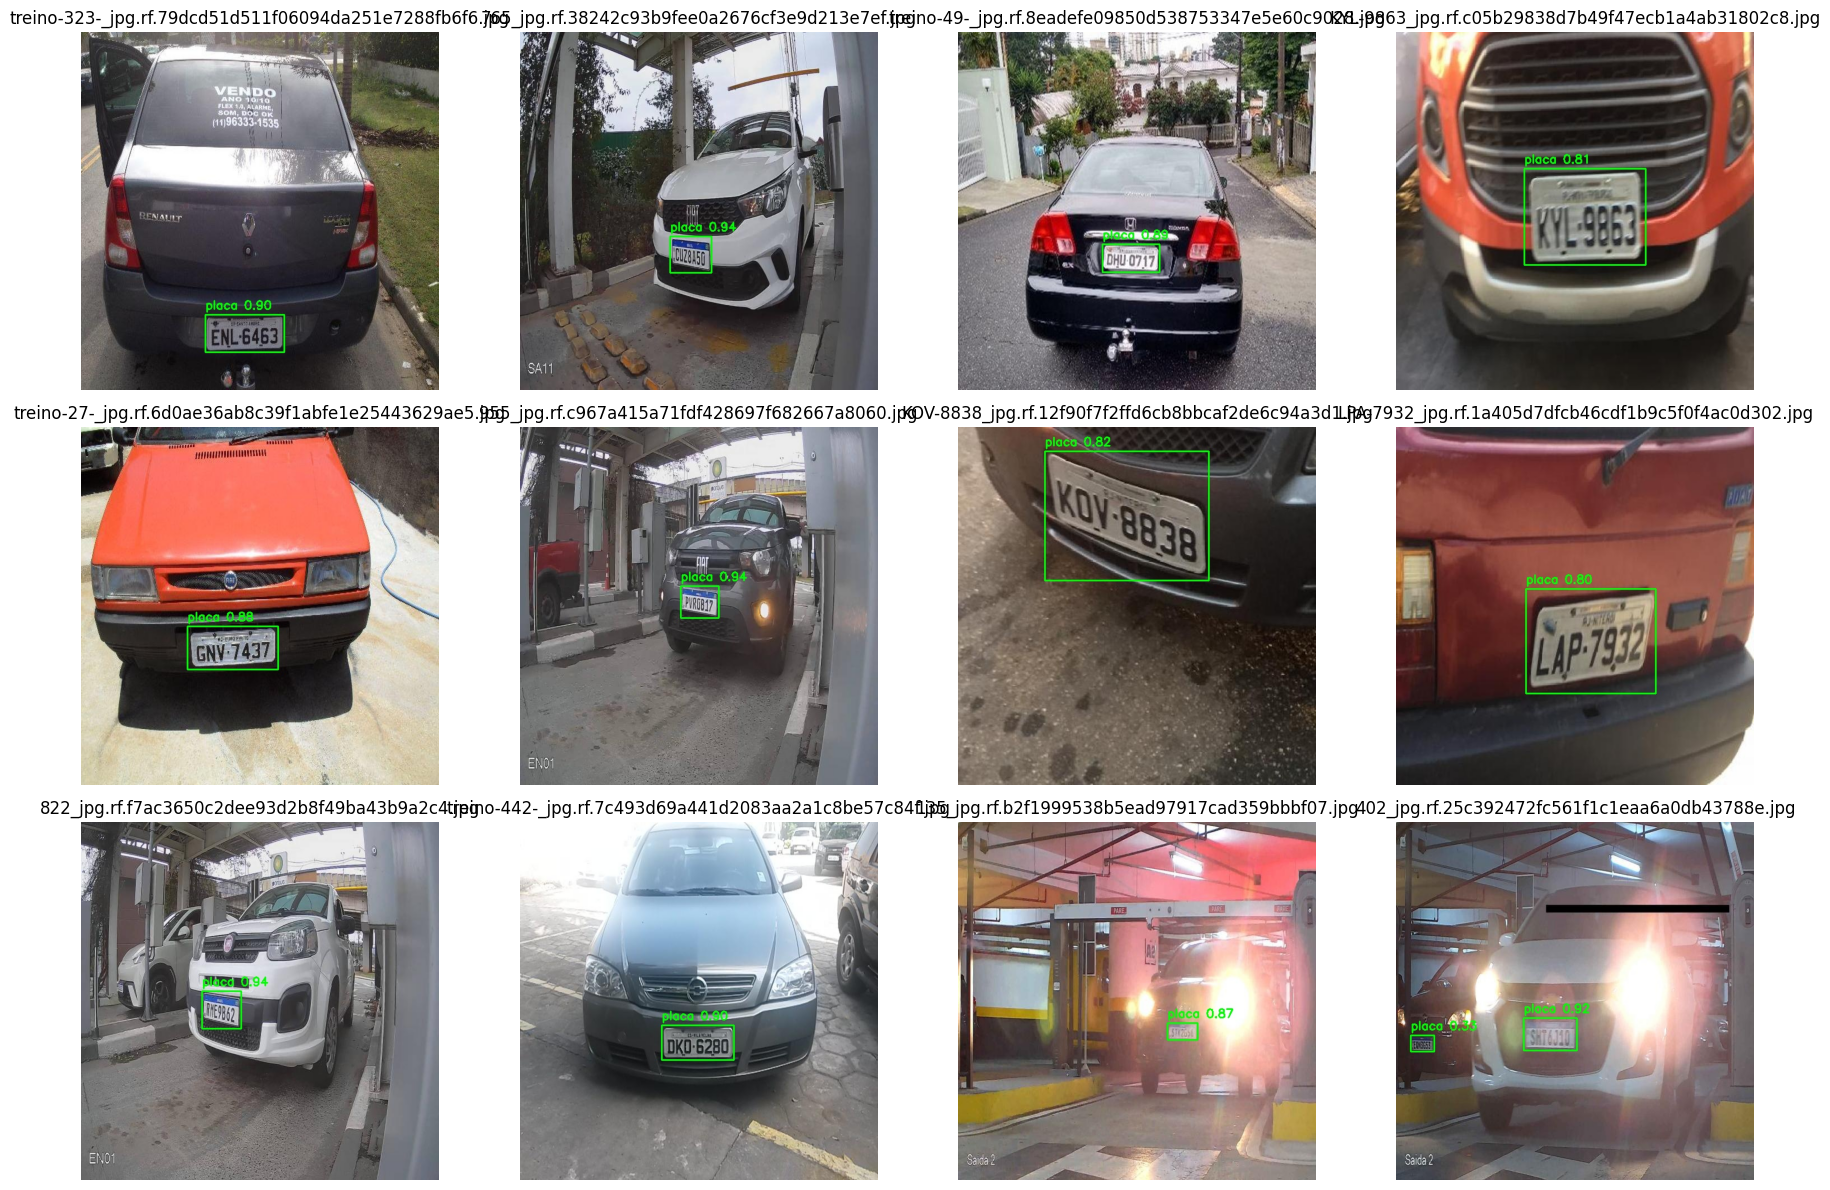

In [10]:
# Visualizar as detecções

result_imgs = [
    f for f in os.listdir(output_detected)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
][:12]

plt.figure(figsize=(18, 12))

for i, img_name in enumerate(result_imgs, 1):
    img_path = os.path.join(output_detected, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 4, i)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

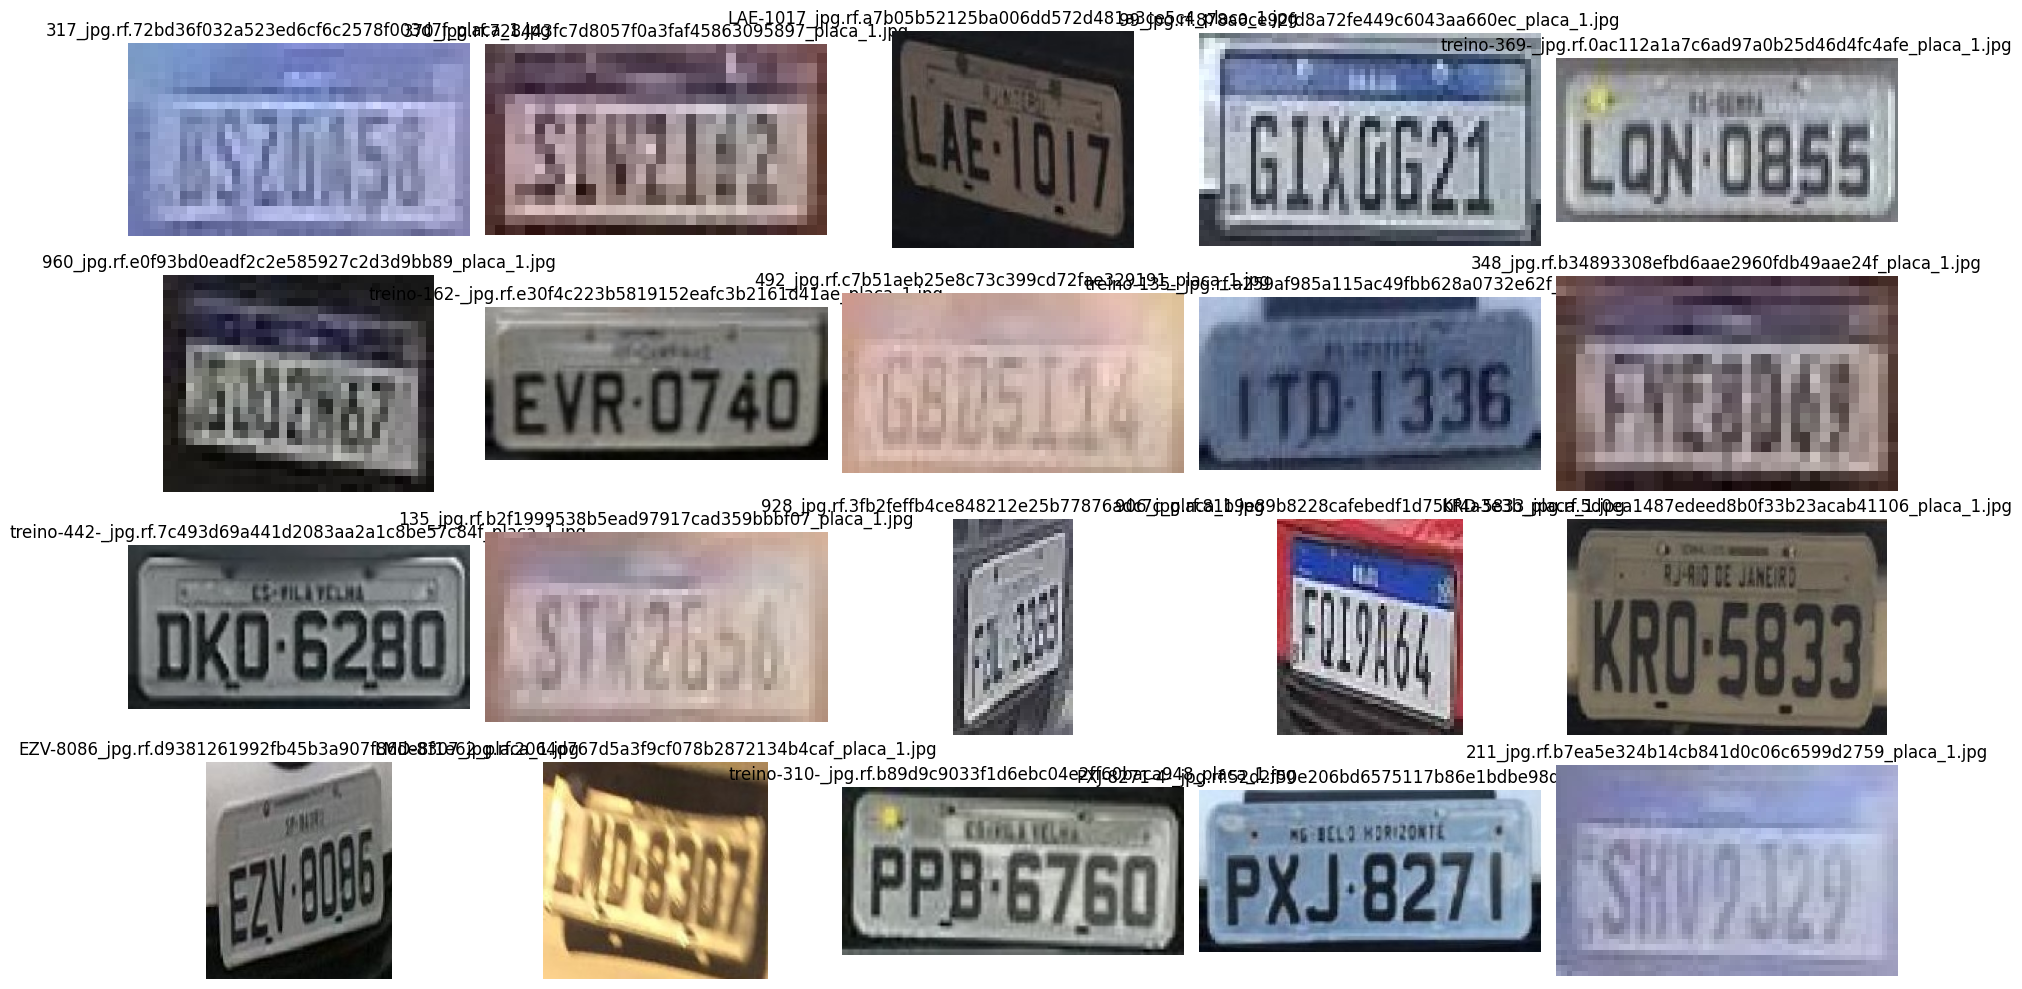

In [11]:
# Visualizar os recortes

crop_imgs = [
    f for f in os.listdir(output_crops)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
][:20]

plt.figure(figsize=(18, 10))

for i, img_name in enumerate(crop_imgs, 1):
    img_path = os.path.join(output_crops, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(4, 5, i)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [12]:
# Criar dataset para HOG + SVM

import random
import numpy as np
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

svm_base = '/kaggle/working/dataset_svm'

for split in ['train', 'valid', 'test']:
    os.makedirs(os.path.join(svm_base, split, 'placa'), exist_ok=True)
    os.makedirs(os.path.join(svm_base, split, 'nao_placa'), exist_ok=True)

print("Pastas do dataset SVM criadas.")

Pastas do dataset SVM criadas.


In [13]:
# Função para converter YOLO para coordenadas reais
# Compatível com label de detecção e segmentação

def yolo_to_xyxy(label_line, img_w, img_h):
    parts = label_line.strip().split()

    if len(parts) < 5:
        raise ValueError(f"Label inválida: {label_line}")

    cls = int(float(parts[0]))
    coords = list(map(float, parts[1:]))

    # Formato YOLO detecção:
    # classe x_center y_center width height
    if len(coords) == 4:
        xc, yc, bw, bh = coords

        x1 = int((xc - bw / 2) * img_w)
        y1 = int((yc - bh / 2) * img_h)
        x2 = int((xc + bw / 2) * img_w)
        y2 = int((yc + bh / 2) * img_h)

    # Formato YOLO segmentação:
    # classe x1 y1 x2 y2 x3 y3 ...
    else:
        if len(coords) % 2 != 0:
            raise ValueError(f"Segmentação com número ímpar de coordenadas: {label_line}")

        xs = coords[0::2]
        ys = coords[1::2]

        x1 = int(min(xs) * img_w)
        y1 = int(min(ys) * img_h)
        x2 = int(max(xs) * img_w)
        y2 = int(max(ys) * img_h)

    x1 = max(0, min(x1, img_w - 1))
    y1 = max(0, min(y1, img_h - 1))
    x2 = max(0, min(x2, img_w))
    y2 = max(0, min(y2, img_h))

    return x1, y1, x2, y2

In [14]:
# Função IoU para evitar que o recorte negativo pegue a placa

def calcular_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter_w = max(0, xB - xA)
    inter_h = max(0, yB - yA)
    inter_area = inter_w * inter_h

    areaA = max(0, boxA[2] - boxA[0]) * max(0, boxA[3] - boxA[1])
    areaB = max(0, boxB[2] - boxB[0]) * max(0, boxB[3] - boxB[1])

    union = areaA + areaB - inter_area

    if union == 0:
        return 0

    return inter_area / union

In [15]:
# Reiniciar dataset SVM para evitar arquivos incompletos antigos

import shutil
import os

svm_base = '/kaggle/working/dataset_svm'

if os.path.exists(svm_base):
    shutil.rmtree(svm_base)

for split in ['train', 'valid', 'test']:
    os.makedirs(os.path.join(svm_base, split, 'placa'), exist_ok=True)
    os.makedirs(os.path.join(svm_base, split, 'nao_placa'), exist_ok=True)

print("Dataset SVM reiniciado.")

Dataset SVM reiniciado.


In [16]:
# Gerar recortes positivos e negativos para o SVM

def gerar_dataset_svm(split):
    img_dir = os.path.join(base_dataset, split, 'images')
    lbl_dir = os.path.join(base_dataset, split, 'labels')

    total_pos = 0
    total_neg = 0

    for img_name in os.listdir(img_dir):
        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        img_path = os.path.join(img_dir, img_name)
        lbl_path = os.path.join(lbl_dir, os.path.splitext(img_name)[0] + '.txt')

        if not os.path.exists(lbl_path):
            continue

        img = cv2.imread(img_path)

        if img is None:
            continue

        h, w = img.shape[:2]

        with open(lbl_path, 'r') as f:
            lines = [line.strip() for line in f if line.strip()]

        if len(lines) == 0:
            continue

        # Usa a primeira placa anotada da imagem
        placa_box = yolo_to_xyxy(lines[0], w, h)

        x1, y1, x2, y2 = placa_box

        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(w, x2)
        y2 = min(h, y2)

        crop_placa = img[y1:y2, x1:x2]

        if crop_placa.size > 0:
            out_pos = os.path.join(
                svm_base,
                split,
                'placa',
                f"{os.path.splitext(img_name)[0]}_pos.jpg"
            )

            cv2.imwrite(out_pos, crop_placa)
            total_pos += 1

        largura = max(30, x2 - x1)
        altura = max(20, y2 - y1)

        tentativas = 0
        negativo_salvo = False

        while tentativas < 80 and not negativo_salvo:
            tentativas += 1

            if w <= largura or h <= altura:
                break

            nx1 = random.randint(0, w - largura)
            ny1 = random.randint(0, h - altura)
            nx2 = nx1 + largura
            ny2 = ny1 + altura

            neg_box = (nx1, ny1, nx2, ny2)

            iou = calcular_iou((x1, y1, x2, y2), neg_box)

            if iou < 0.05:
                crop_neg = img[ny1:ny2, nx1:nx2]

                if crop_neg.size > 0:
                    out_neg = os.path.join(
                        svm_base,
                        split,
                        'nao_placa',
                        f"{os.path.splitext(img_name)[0]}_neg.jpg"
                    )

                    cv2.imwrite(out_neg, crop_neg)
                    total_neg += 1
                    negativo_salvo = True

    print(f"{split}: positivos={total_pos}, negativos={total_neg}")


gerar_dataset_svm('train')
gerar_dataset_svm('valid')
gerar_dataset_svm('test')

train: positivos=4220, negativos=4184
valid: positivos=391, negativos=386
test: positivos=276, negativos=270


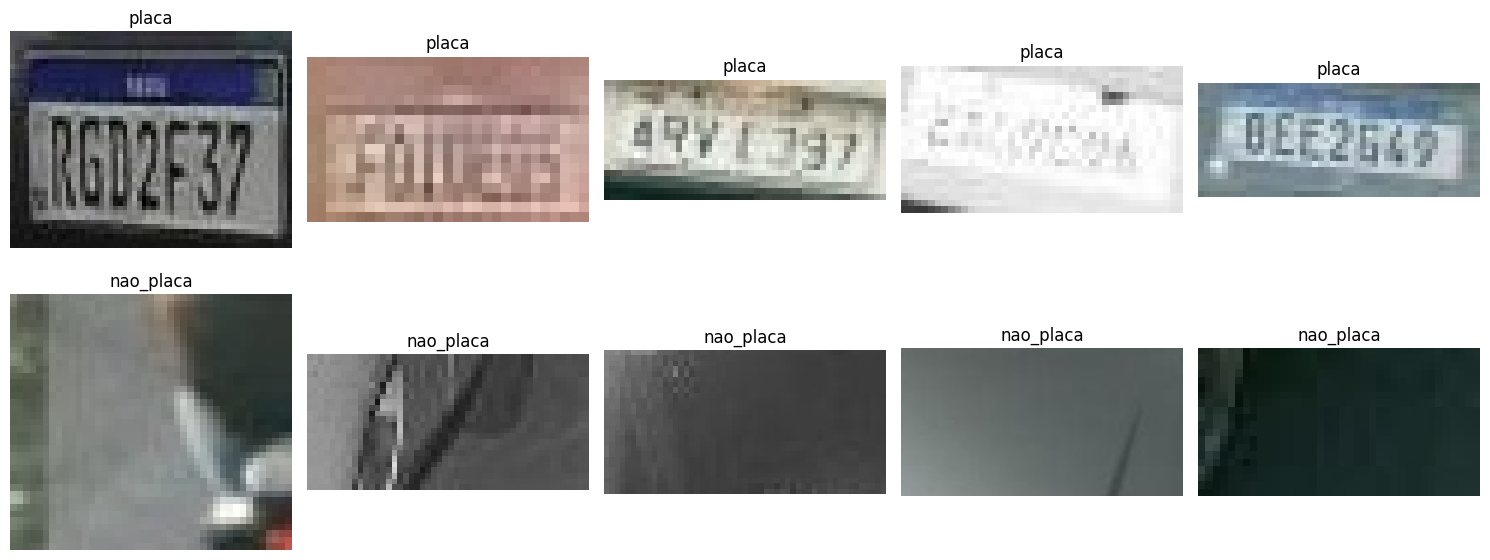

In [17]:
# Visualizar alguns exemplos do dataset SVM

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

placas = os.listdir(os.path.join(svm_base, 'train', 'placa'))[:5]
nao_placas = os.listdir(os.path.join(svm_base, 'train', 'nao_placa'))[:5]

for i, img_name in enumerate(placas):
    img_path = os.path.join(svm_base, 'train', 'placa', img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[0, i].imshow(img)
    axes[0, i].set_title('placa')
    axes[0, i].axis('off')

for i, img_name in enumerate(nao_placas):
    img_path = os.path.join(svm_base, 'train', 'nao_placa', img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[1, i].imshow(img)
    axes[1, i].set_title('nao_placa')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [18]:
# Extrair características HOG

def extrair_hog_da_imagem(img_path):
    img = cv2.imread(img_path)

    if img is None:
        return None

    img = cv2.resize(img, (128, 64))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )

    return features


def carregar_dataset_hog(split):
    X = []
    y = []

    classes_svm = {
        'nao_placa': 0,
        'placa': 1
    }

    for nome_classe, label in classes_svm.items():
        pasta = os.path.join(svm_base, split, nome_classe)

        for img_name in os.listdir(pasta):
            if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            img_path = os.path.join(pasta, img_name)
            features = extrair_hog_da_imagem(img_path)

            if features is not None:
                X.append(features)
                y.append(label)

    return np.array(X), np.array(y)


X_train, y_train = carregar_dataset_hog('train')
X_valid, y_valid = carregar_dataset_hog('valid')
X_test, y_test = carregar_dataset_hog('test')

print("Treino:", X_train.shape, y_train.shape)
print("Validação:", X_valid.shape, y_valid.shape)
print("Teste:", X_test.shape, y_test.shape)

Treino: (8404, 3780) (8404,)
Validação: (777, 3780) (777,)
Teste: (546, 3780) (546,)


In [19]:
# Treinar SVM com Grid Search

import time

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm = SVC()

grid = GridSearchCV(
    svm,
    param_grid,
    cv=3,
    scoring='f1',
    verbose=2,
    n_jobs=-1
)

inicio_svm = time.time()

grid.fit(X_train, y_train)

fim_svm = time.time()

tempo_treino_svm = fim_svm - inicio_svm

print("Melhores parâmetros:", grid.best_params_)
print("Melhor F1 na validação cruzada:", grid.best_score_)
print(f"Tempo de treinamento SVM: {tempo_treino_svm:.2f} segundos")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Melhores parâmetros: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Melhor F1 na validação cruzada: 0.9935873629869905
Tempo de treinamento SVM: 364.94 segundos


In [20]:
# Avaliar o SVM no teste

best_svm = grid.best_estimator_

inicio_eval_svm = time.time()

y_pred = best_svm.predict(X_test)

fim_eval_svm = time.time()

tempo_eval_svm = fim_eval_svm - inicio_eval_svm

acc_svm = accuracy_score(y_test, y_pred)
precision_svm = precision_score(y_test, y_pred)
recall_svm = recall_score(y_test, y_pred)
f1_svm = f1_score(y_test, y_pred)

print("Acurácia:", acc_svm)
print("Precisão:", precision_svm)
print("Recall:", recall_svm)
print("F1-score:", f1_svm)
print(f"Tempo de avaliação SVM: {tempo_eval_svm:.2f} segundos")

print("\nRelatório de classificação:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['nao_placa', 'placa']
))

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred))

Acurácia: 0.9981684981684982
Precisão: 1.0
Recall: 0.9963768115942029
F1-score: 0.9981851179673321
Tempo de avaliação SVM: 1.40 segundos

Relatório de classificação:
              precision    recall  f1-score   support

   nao_placa       1.00      1.00      1.00       270
       placa       1.00      1.00      1.00       276

    accuracy                           1.00       546
   macro avg       1.00      1.00      1.00       546
weighted avg       1.00      1.00      1.00       546


Matriz de confusão:
[[270   0]
 [  1 275]]


In [21]:
# Detector HOG + SVM com Sliding Window
# Avaliação completa no conjunto de teste

import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def extrair_hog_crop_rgb(crop_rgb):
    """
    Extrai características HOG de um recorte em RGB.
    O tamanho precisa ser o mesmo usado no treinamento do SVM: 128x64.
    """

    crop_resized = cv2.resize(crop_rgb, (128, 64))
    gray = cv2.cvtColor(crop_resized, cv2.COLOR_RGB2GRAY)

    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )

    return features.reshape(1, -1)


def detector_hog_svm_sliding_window(
    img_rgb,
    svm_model,
    window_size=(128, 64),
    stride=32,
    scales=[0.75, 1.0, 1.25, 1.5, 1.75, 2.0]
):
    """
    Detecta a placa na imagem inteira usando HOG + SVM com janelas deslizantes.
    """

    h_img, w_img = img_rgb.shape[:2]

    best_score = -999999
    best_box = None
    total_janelas = 0

    base_w, base_h = window_size

    for scale in scales:
        win_w = int(base_w * scale)
        win_h = int(base_h * scale)

        if win_w >= w_img or win_h >= h_img:
            continue

        for y in range(0, h_img - win_h, stride):
            for x in range(0, w_img - win_w, stride):
                crop = img_rgb[y:y + win_h, x:x + win_w]

                if crop.size == 0:
                    continue

                features = extrair_hog_crop_rgb(crop)
                pred = svm_model.predict(features)[0]

                if hasattr(svm_model, "decision_function"):
                    score = float(svm_model.decision_function(features)[0])
                else:
                    score = 1.0 if pred == 1 else 0.0

                total_janelas += 1

                if pred == 1 and score > best_score:
                    best_score = score
                    best_box = (x, y, x + win_w, y + win_h)

    return best_box, best_score, total_janelas


# Avaliar o detector HOG + SVM no conjunto de teste completo

test_images_path = os.path.join(base_dataset, 'test', 'images')
test_labels_path = os.path.join(base_dataset, 'test', 'labels')

imagens_teste = [
    f for f in os.listdir(test_images_path)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

resultados_hog_svm_detector = []

tp = 0
fp = 0
fn = 0

iou_threshold = 0.5
tempos = []

output_hog_svm = '/kaggle/working/resultado_hog_svm_detector'
os.makedirs(output_hog_svm, exist_ok=True)

for img_name in imagens_teste:
    img_path = os.path.join(test_images_path, img_name)
    lbl_path = os.path.join(test_labels_path, os.path.splitext(img_name)[0] + '.txt')

    img_bgr = cv2.imread(img_path)

    if img_bgr is None:
        continue

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    # Ler bounding box real
    true_box = None

    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            lines = [line.strip() for line in f if line.strip()]

        if len(lines) > 0:
            true_box = yolo_to_xyxy(lines[0], w, h)

    inicio = time.time()

    pred_box, score, total_janelas = detector_hog_svm_sliding_window(
        img_rgb,
        best_svm,
        window_size=(128, 64),
        stride=32,
        scales=[0.75, 1.0, 1.25, 1.5, 1.75, 2.0]
    )

    fim = time.time()
    tempo = fim - inicio
    tempos.append(tempo)

    iou = 0.0
    status = "nao_detectado"

    img_plot = img_rgb.copy()

    if true_box is not None:
        tx1, ty1, tx2, ty2 = true_box

        # Caixa real em verde
        cv2.rectangle(
            img_plot,
            (tx1, ty1),
            (tx2, ty2),
            (0, 255, 0),
            2
        )

        cv2.putText(
            img_plot,
            "real",
            (tx1, max(20, ty1 - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

    if pred_box is not None:
        px1, py1, px2, py2 = pred_box

        # Caixa prevista em azul
        cv2.rectangle(
            img_plot,
            (px1, py1),
            (px2, py2),
            (255, 0, 0),
            2
        )

        cv2.putText(
            img_plot,
            f"HOG+SVM {score:.2f}",
            (px1, max(20, py1 - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )

    if true_box is not None and pred_box is not None:
        iou = calcular_iou(true_box, pred_box)

        if iou >= iou_threshold:
            tp += 1
            status = "correto"
        else:
            fp += 1
            fn += 1
            status = "incorreto"

    elif true_box is not None and pred_box is None:
        fn += 1
        status = "nao_detectado"

    elif true_box is None and pred_box is not None:
        fp += 1
        status = "falso_positivo"

    else:
        status = "sem_placa_e_sem_deteccao"

    output_img_path = os.path.join(output_hog_svm, img_name)
    cv2.imwrite(output_img_path, cv2.cvtColor(img_plot, cv2.COLOR_RGB2BGR))

    resultados_hog_svm_detector.append({
        "Imagem": img_name,
        "Status": status,
        "Score": score,
        "IoU": iou,
        "Total_Janelas": total_janelas,
        "Tempo_s": tempo,
        "True_Box": true_box,
        "Pred_Box": pred_box
    })


df_hog_svm_detector = pd.DataFrame(resultados_hog_svm_detector)

precision_hog_detector = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_hog_detector = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_hog_detector = (
    2 * precision_hog_detector * recall_hog_detector / (precision_hog_detector + recall_hog_detector)
    if (precision_hog_detector + recall_hog_detector) > 0
    else 0
)

iou_medio_hog_detector = df_hog_svm_detector["IoU"].mean()
tempo_medio_hog_detector = np.mean(tempos)

metricas_hog_svm_detector = pd.DataFrame({
    "Modelo": ["HOG + SVM Detector"],
    "TP": [tp],
    "FP": [fp],
    "FN": [fn],
    "Precision": [precision_hog_detector],
    "Recall": [recall_hog_detector],
    "F1-score": [f1_hog_detector],
    "IoU_medio": [iou_medio_hog_detector],
    "Tempo_medio_s": [tempo_medio_hog_detector],
    "IoU_threshold": [iou_threshold]
})

df_hog_svm_detector.to_csv(
    '/kaggle/working/resultados_hog_svm_detector.csv',
    index=False
)

metricas_hog_svm_detector.to_csv(
    '/kaggle/working/metricas_hog_svm_detector.csv',
    index=False
)

print("Avaliação do detector HOG + SVM finalizada.")
print("TP:", tp)
print("FP:", fp)
print("FN:", fn)
print("Precision:", precision_hog_detector)
print("Recall:", recall_hog_detector)
print("F1-score:", f1_hog_detector)
print("IoU médio:", iou_medio_hog_detector)
print("Tempo médio:", tempo_medio_hog_detector)

metricas_hog_svm_detector

[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=  56.1s
[CV] END ......................C=0.1, gamma=auto, kernel=rbf; total time= 3.2min
[CV] END ........................C=1, gamma=auto, kernel=rbf; total time= 1.0min
[CV] END ......................C=10, gamma=scale, kernel=rbf; total time=  30.8s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=  12.3s
[CV] END ...................C=0.1, gamma=auto, kernel=linear; total time=  12.0s
[CV] END ...................C=0.1, gamma=auto, kernel=linear; total time=  10.7s
[CV] END ...................C=0.1, gamma=auto, kernel=linear; total time=   8.6s
[CV] END ......................C=0.1, gamma=auto, kernel=rbf; total time= 3.4min
[CV] END ........................C=1, gamma=auto, kernel=rbf; total time= 1.1min
[CV] END ....................C=10, gamma=auto, kernel=linear; total time=  11.2s
[CV] END .......................C=10, gamma=auto, kernel=rbf; total time=  19.1s
[CV] END ..................C

,Modelo,TP,FP,FN,Precision,Recall,F1-score,IoU_medio,Tempo_medio_s,IoU_threshold
0,HOG + SVM Detector,127,138,149,0.479245,0.460145,0.469501,0.369927,10.27482,0.5


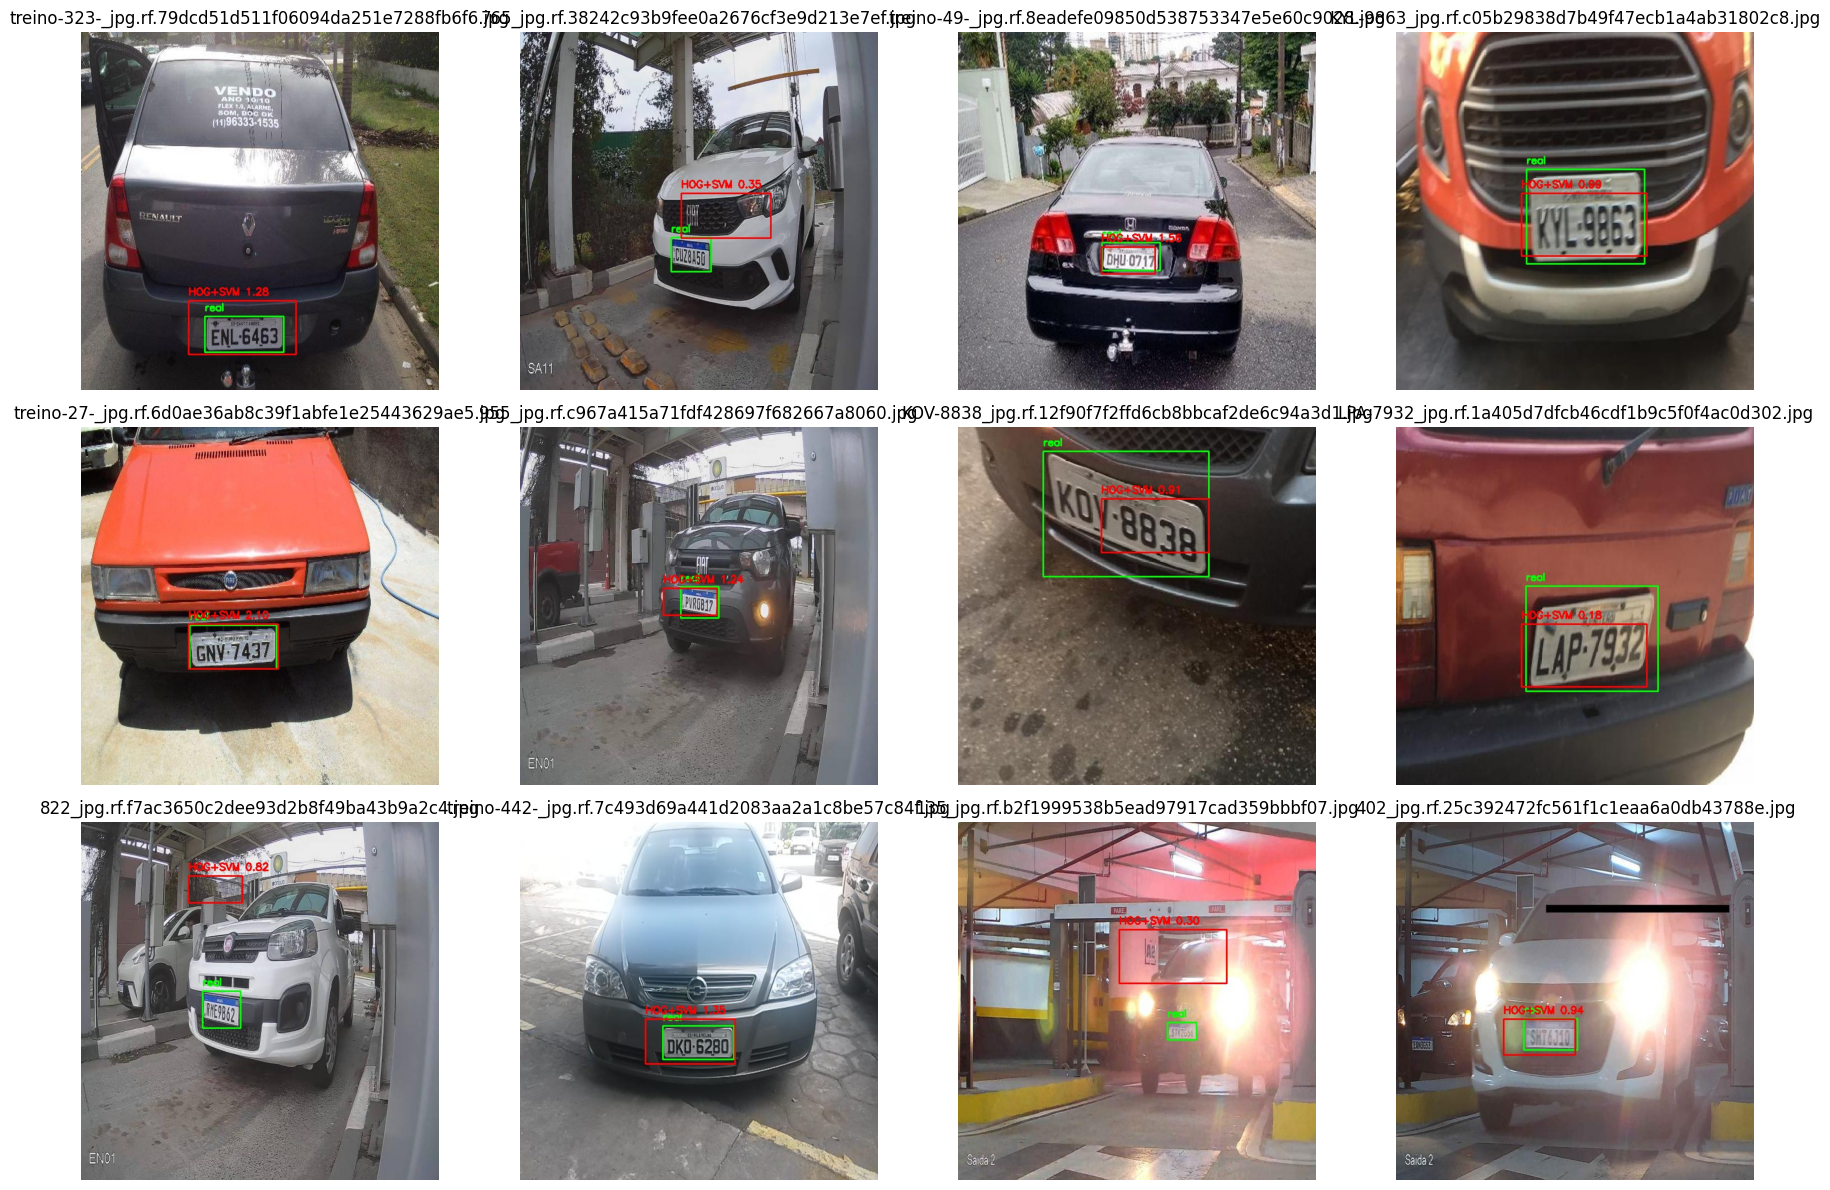

In [22]:
# Visualizar algumas detecções do HOG + SVM

result_imgs_hog = [
    f for f in os.listdir(output_hog_svm)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
][:12]

plt.figure(figsize=(18, 12))

for i, img_name in enumerate(result_imgs_hog, 1):
    img_path = os.path.join(output_hog_svm, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 4, i)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [23]:
# Salvar resultados do detector HOG + SVM

df_hog_svm_detector.to_csv(
    '/kaggle/working/resultados_hog_svm_detector.csv',
    index=False
)

print("Resultados do detector HOG + SVM salvos em:")
print("/kaggle/working/resultados_hog_svm_detector.csv")

Resultados do detector HOG + SVM salvos em:
/kaggle/working/resultados_hog_svm_detector.csv


In [24]:
# Criar tabela de comparação dos modelos

precision_yolo = float(metrics.box.mp)
recall_yolo = float(metrics.box.mr)
map50_yolo = float(metrics.box.map50)
map5095_yolo = float(metrics.box.map)

f1_yolo = (
    2 * precision_yolo * recall_yolo / (precision_yolo + recall_yolo)
    if (precision_yolo + recall_yolo) > 0
    else 0
)

comparacao = pd.DataFrame({
    'Modelo': ['YOLOv11', 'HOG + SVM'],
    'Tipo': [
        'Deep Learning - Detector de Objetos',
        'Machine Learning clássico - Detector por Sliding Window'
    ],
    'Treinamento': [
        'Treinado com imagens completas e labels YOLO',
        'Treinado com recortes placa/não placa e aplicado com janelas deslizantes'
    ],
    'Entrada na detecção': [
        'Imagem completa',
        'Imagem completa'
    ],
    'Saída': [
        'Bounding box da placa',
        'Bounding box da placa'
    ],
    'Precision': [
        precision_yolo,
        precision_hog_detector
    ],
    'Recall': [
        recall_yolo,
        recall_hog_detector
    ],
    'F1-score': [
        f1_yolo,
        f1_hog_detector
    ],
    'mAP50': [
        map50_yolo,
        None
    ],
    'mAP50-95': [
        map5095_yolo,
        None
    ],
    'IoU_medio': [
        None,
        iou_medio_hog_detector
    ],
    'Tempo_medio_s': [
        None,
        tempo_medio_hog_detector
    ],
    'Observação': [
        'Modelo mais adequado para detecção direta de objetos',
        'Modelo interpretável, porém mais lento e dependente das janelas'
    ]
})

comparacao

,Modelo,Tipo,Treinamento,Entrada na detecção,Saída,Precision,Recall,F1-score,mAP50,mAP50-95,IoU_medio,Tempo_medio_s,Observação
0,YOLOv11,Deep Learning - Detector de Objetos,Treinado com imagens completas e labels YOLO,Imagem completa,Bounding box da placa,0.998486,0.992806,0.995638,0.995,0.826291,NaN,NaN,Modelo mais adequado para detecção direta de o...
1,HOG + SVM,Machine Learning clássico - Detector por Slidi...,Treinado com recortes placa/não placa e aplica...,Imagem completa,Bounding box da placa,0.479245,0.460145,0.469501,NaN,NaN,0.369927,10.27482,"Modelo interpretável, porém mais lento e depen..."


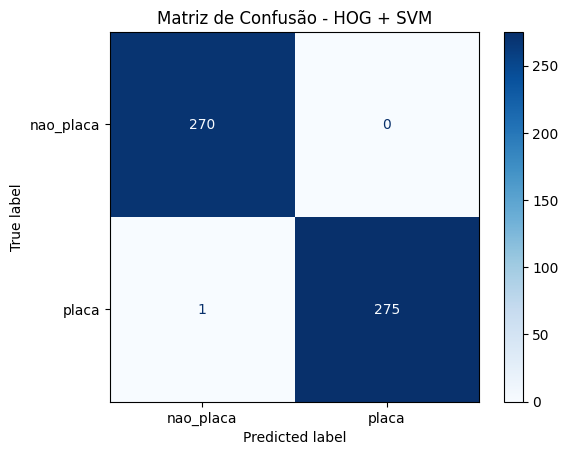

Arquivos finais salvos:
✅ /kaggle/working/svm_model.pkl
✅ /kaggle/working/metricas_svm.csv
✅ /kaggle/working/confusion_matrix_svm.png
✅ /kaggle/working/resultados_yolo.csv
✅ /kaggle/working/resultados_hog_svm_detector.csv
✅ /kaggle/working/metricas_hog_svm_detector.csv
✅ /kaggle/working/comparacao_modelos.csv
✅ /kaggle/working/recortes_placas
✅ /kaggle/working/resultado_deteccoes


In [25]:
# Salvar resultados finais

import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Garante que o modelo SVM final existe na memória
best_svm = grid.best_estimator_

# Recalcula a avaliação do SVM no teste
inicio_eval_svm = time.time()

y_pred = best_svm.predict(X_test)

fim_eval_svm = time.time()

tempo_eval_svm = fim_eval_svm - inicio_eval_svm

acc_svm = accuracy_score(y_test, y_pred)
precision_svm = precision_score(y_test, y_pred)
recall_svm = recall_score(y_test, y_pred)
f1_svm = f1_score(y_test, y_pred)

# Salvar modelo SVM
svm_model_path = '/kaggle/working/svm_model.pkl'
joblib.dump(best_svm, svm_model_path)

# Salvar métricas do SVM
metricas_svm = pd.DataFrame({
    'Modelo': ['HOG + SVM'],
    'Acuracia': [acc_svm],
    'Precisao': [precision_svm],
    'Recall': [recall_svm],
    'F1-score': [f1_svm],
    'Tempo_Avaliacao_s': [tempo_eval_svm],
    'Melhores_Parametros': [str(grid.best_params_)],
    'Melhor_F1_GridSearch': [grid.best_score_]
})

metricas_svm.to_csv('/kaggle/working/metricas_svm.csv', index=False)

# Salvar matriz de confusão do SVM
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['nao_placa', 'placa']
)

disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusão - HOG + SVM')
plt.savefig('/kaggle/working/confusion_matrix_svm.png', dpi=300, bbox_inches='tight')
plt.show()

# Salvar comparação dos modelos
comparacao.to_csv('/kaggle/working/comparacao_modelos.csv', index=False)

# Conferir arquivos criados
arquivos_finais = [
    '/kaggle/working/svm_model.pkl',
    '/kaggle/working/metricas_svm.csv',
    '/kaggle/working/confusion_matrix_svm.png',
    '/kaggle/working/resultados_yolo.csv',
    '/kaggle/working/resultados_hog_svm_detector.csv',
    '/kaggle/working/metricas_hog_svm_detector.csv',
    '/kaggle/working/comparacao_modelos.csv'
]

print("Arquivos finais salvos:")

for arquivo in arquivos_finais:
    if os.path.exists(arquivo):
        print(f"✅ {arquivo}")
    else:
        print(f"❌ Não encontrado: {arquivo}")

print("✅ /kaggle/working/recortes_placas")
print("✅ /kaggle/working/resultado_deteccoes")